max ev: 19.408975736238997, number above threshold: 7
7.067999836939229


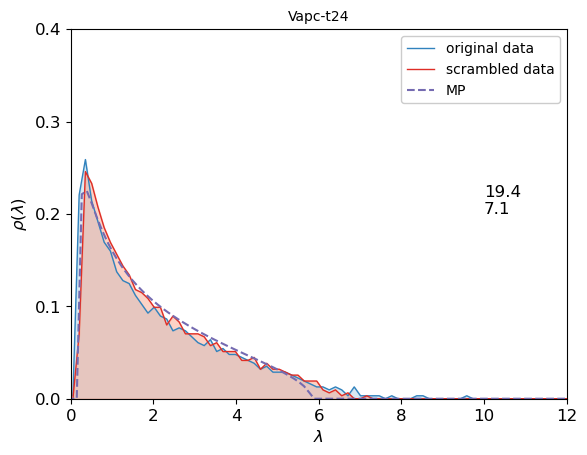

In [215]:
import src.analysis_functions as af
import src.data_functions as df
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import importlib



importlib.reload(af)
importlib.reload(df)

fsize=12

def get_data_for_plot(path, norm=True, log=False, norm_method='sum', norm_sum=1):
    # get annotated matrix from file
    amat = df.read_from_csv(path)
    # calculate the eigenvalues and plot:
    # remove tracker genes from the matrix
    t_genes = ['16s_mature', '16s_unprocessed']
    # amat.reset_filters()
    index = [np.where(amat.var_names == val)[0][0] for val in t_genes if val in amat.var_names]
    # filter the genes
    amat.filtered_var[np.array(index).astype(int)] = False
    m = amat.get_filtered_matrix().m
    pcs, pcs1, m = af.get_eig_dist(m, norm=norm, log=log, norm_method=norm_method, norm_sum=norm_sum)
    return pcs, pcs1, m.shape[0], m

def plot_eigvals(ax, pcs, pcs1, N, x_max, y_max, n_bins, x_label=True, y_label=True):
    # plot the eigenvalue distribution of the normalized filtered matrix
    # define limits and bin number
    P = len(pcs)
    scale = 1  # scale factor for the Marchenko-Pastur distribution
    edges = np.linspace(-0.1, x_max, num=n_bins)

    # remove zeros in pcs and pcs1
    # if alpha>1 adjust the scale factor to match theoretical results
    if P / N > 1:
        scale = N / P
        pcs = pcs[pcs != 0]
        pcs1 = pcs1[pcs1 != 0]

    # first plot
    counts, bins = np.histogram(pcs, bins=edges, density=True)
    ax.plot(bins[1:], scale * counts, color='#3182bd', linewidth=1, label='original data')
    ax.fill_between(bins[1:], scale * counts, 0, color='#9ecae1', alpha=.4)
    # second plot
    counts, bins = np.histogram(pcs1, bins=edges, density=True)
    ax.plot(bins[1:], scale * counts, color='#de2d26', linewidth=1, label='scrambled data')
    ax.fill_between(bins[1:], scale * counts, 0, color='#fc9272', alpha=.4)
    # plot analytical Marchenko-Pastur distribution
    x = np.linspace(-0.1, x_max, 100)
    y = [af.mp_distribution(val, P / N) for val in x]
    ax.plot(x, y, color='#756bb1', linestyle='dashed', label='MP')
    # labels and limits
    if x_label:
        ax.set_xlabel("$\lambda$", fontsize=fsize)
    if y_label:
        ax.set_ylabel(r"$\rho(\lambda)$", fontsize=fsize)
    ax.set_ylim(0, y_max)
    ax.set_xlim(0, x_max)
    # set x_ticks with difference of 2
    ax.set_xticks(np.arange(0, (x_max // 2) * 2 + 2, 2))
    # set y_ticks with difference of 0.1
    ax.set_yticks(np.arange(0, (y_max // 0.1) * 0.1 + 0.1, 0.1))
    ax.legend(facecolor='white', framealpha=1, fontsize=fsize-2, loc='upper right')
    # set the font size of the ticks
    ax.tick_params(axis='both', which='major', labelsize=fsize)

nbins = 81
x_max = 12
y_max = 0.4
fig, ax = plt.subplots()
# plot individual distributions
norm = True
log = False
norm_method = 'sum'
norm_sum = 100
# set style to default
plt.style.use('default')
plt.rcParams.update({'font.size': fsize})
# create grid of experimental results
# subplot 1
# get annotated matrix from file
root_dir = r"C:\Users\owner\Documents\Projects\dysregulated-persistence"
file_name = ('sample_2b_filtered.csv')
path = os.path.join(root_dir,'data_for_paper', file_name)
pcs, pcs1, N, m = get_data_for_plot(path, norm=norm, log=log, norm_method=norm_method, norm_sum=norm_sum)
ax.set_title('Vapc-t24', fontsize=fsize-2)
ax.text(10,0.2,f'{np.max(pcs):.1f}\n{np.max(pcs1):.1f}')
plot_eigvals(ax,pcs, pcs1, N, x_max, y_max, nbins)
print(f'max ev: {np.max(pcs)}, number above threshold: {sum(pcs>np.max(pcs1))}')
print(np.max(pcs1))